In [10]:
import pandas as pd
import seaborn
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

In [11]:
lang_compare = pd.read_csv("among_lang_metrics.csv", index_col=0)
baseline_compare = pd.read_csv("between_lang_baseline_metrics.csv", index_col=0)

In [12]:
lang_compare.head() # compare between languages eg french1<->english1, french2<->english2, french3<->english3 ... 
                    # and between baselines eg baseline_french1<->baseline_english1 ...

,Model,Question,Cosine,fBaseline,Language1-Language2
0,Qwen3-32B,Question 1,0.9358,False,NL-EN
1,Qwen3-32B,Question 1,0.9361,False,NL-EN
2,Qwen3-32B,Question 1,0.9462,False,NL-EN
3,Qwen3-32B,Question 1,0.9462,False,NL-EN
4,Qwen3-32B,Question 1,0.9453,False,NL-EN


In [13]:
baseline_compare.head() # compare specific language and its baseline eg french1<->baseline_french1, french2<->baseline_french2 ...

,Model,Question,Language,Cosine,Rouge
0,Qwen3-32B,Question 1,NL,0.9173,0.2600
1,Qwen3-32B,Question 1,NL,0.9105,0.2626
2,Qwen3-32B,Question 1,NL,0.9320,0.2591
3,Qwen3-32B,Question 1,NL,0.9314,0.2604
4,Qwen3-32B,Question 1,NL,0.8965,0.2653


In [14]:
lang_compare.drop("Question", axis=1).groupby(["Model","Language1-Language2", "fBaseline"]).agg(['mean', 'std', 'count'])

Cosine                
                                             mean       std count
Model     Language1-Language2 fBaseline                          
Qwen3-32B EN-FR               False      0.838019  0.043733  1100
                              True       0.855092  0.041900  1100
          NL-EN               False      0.849481  0.063678  1100
                              True       0.862156  0.043650  1100
          NL-FR               False      0.784822  0.072078  1100
                              True       0.820637  0.040985  1100

In [15]:
lang_compare.groupby(["Model","Question","Language1-Language2", "fBaseline"]).agg(['mean', 'std', 'count'])

Cosine                
                                                        mean       std count
Model     Question   Language1-Language2 fBaseline                          
Qwen3-32B Question 1 EN-FR               False      0.875960  0.011511   100
                                         True       0.904202  0.005571   100
                     NL-EN               False      0.940659  0.011935   100
                                         True       0.929012  0.013000   100
                     NL-FR               False      0.852528  0.018979   100
...                                                      ...       ...   ...
          Question 9 EN-FR               True       0.784799  0.021092   100
                     NL-EN               False      0.860226  0.011516   100
                                         True       0.827195  0.021590   100
                     NL-FR               False      0.803997  0.019595   100
                                         True       0.828032  0.038334   100

[66 rows x 3 columns]

In [16]:
baseline_compare.drop("Question", axis=1).groupby(["Model", "Language"]).agg(["mean", "count"])

Cosine           Rouge      
                        mean count      mean count
Model     Language                                
Qwen3-32B EN        0.923821  1100  0.268407  1100
          FR        0.878665  1100  0.251704  1100
          NL        0.852181  1100  0.240205  1100

In [17]:
baseline_compare.groupby(["Model", "Question", "Language"]).agg(["mean", "count"])

Cosine           Rouge      
                                    mean count      mean count
Model     Question    Language                                
Qwen3-32B Question 1  EN        0.968682   100  0.350853   100
                      FR        0.912669   100  0.313529   100
                      NL        0.923673   100  0.274116   100
          Question 10 EN        0.903005   100  0.175868   100
                      FR        0.894315   100  0.201942   100
                      NL        0.870424   100  0.206445   100
          Question 11 EN        0.937901   100  0.229123   100
                      FR        0.905559   100  0.270888   100
                      NL        0.864987   100  0.249658   100
          Question 2  EN        0.954858   100  0.305512   100
                      FR        0.866949   100  0.233667   100
                      NL        0.814052   100  0.189090   100
          Question 3  EN        0.902383   100  0.222215   100
                      FR        0.852994   100  0.249239   100
                      NL        0.778419   100  0.177532   100
          Question 4  EN        0.822578   100  0.177807   100
                      FR        0.857147   100  0.268801   100
                      NL        0.730599   100  0.197092   100
          Question 5  EN        0.958253   100  0.310472   100
                      FR        0.865888   100  0.222266   100
                      NL        0.932707   100  0.373726   100
          Question 6  EN        0.957240   100  0.396709   100
                      FR        0.927563   100  0.213456   100
                      NL        0.883802   100  0.256787   100
          Question 7  EN        0.940365   100  0.307365   100
                      FR        0.856867   100  0.258760   100
                      NL        0.815271   100  0.206754   100
          Question 8  EN        0.916762   100  0.240336   100
                      FR        0.854616   100  0.273815   100
                      NL        0.875788   100  0.206747   100
          Question 9  EN        0.900008   100  0.236217   100
                      FR        0.870750   100  0.262377   100
                      NL        0.884274   100  0.304312   100

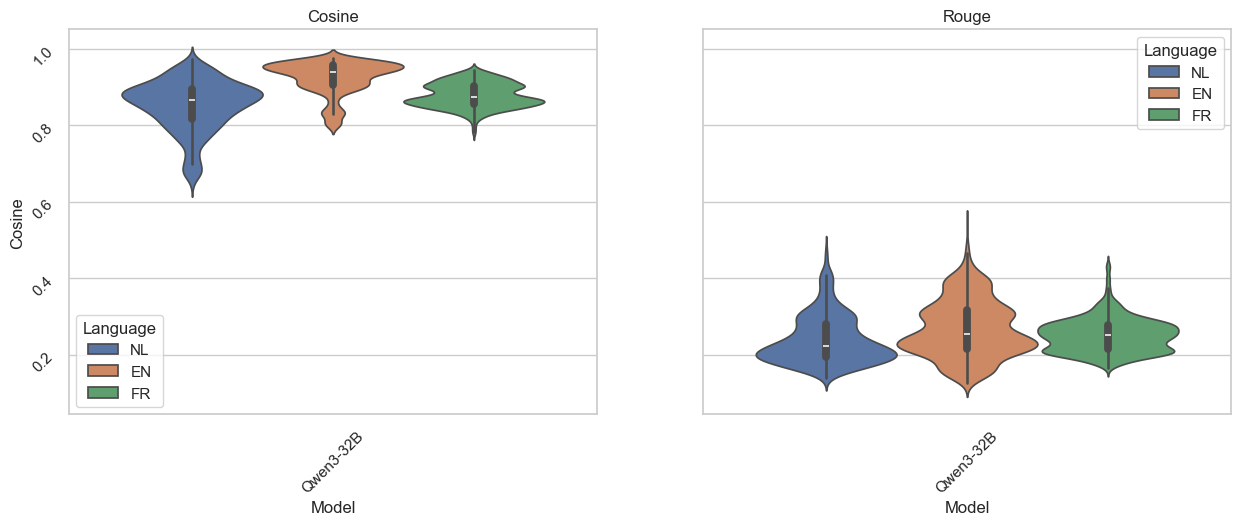

In [18]:
seaborn.set(style = 'whitegrid')  
ys = ["Cosine", "Rouge"]
fig, axs = plt.subplots(ncols=len(ys), figsize=(15,5), sharey=True)

# not between questions, each violin plot has 24 data points
for i in range(len(ys)):
    axs[i].tick_params(labelrotation=45)   
    axs[i].title.set_text(ys[i])
    seaborn.violinplot(x="Model", 
                       y=ys[i], 
                       hue="Language",
                       data=baseline_compare,
                       density_norm='count',
                       ax=axs[i])

TypeError: 'Axes' object is not subscriptable

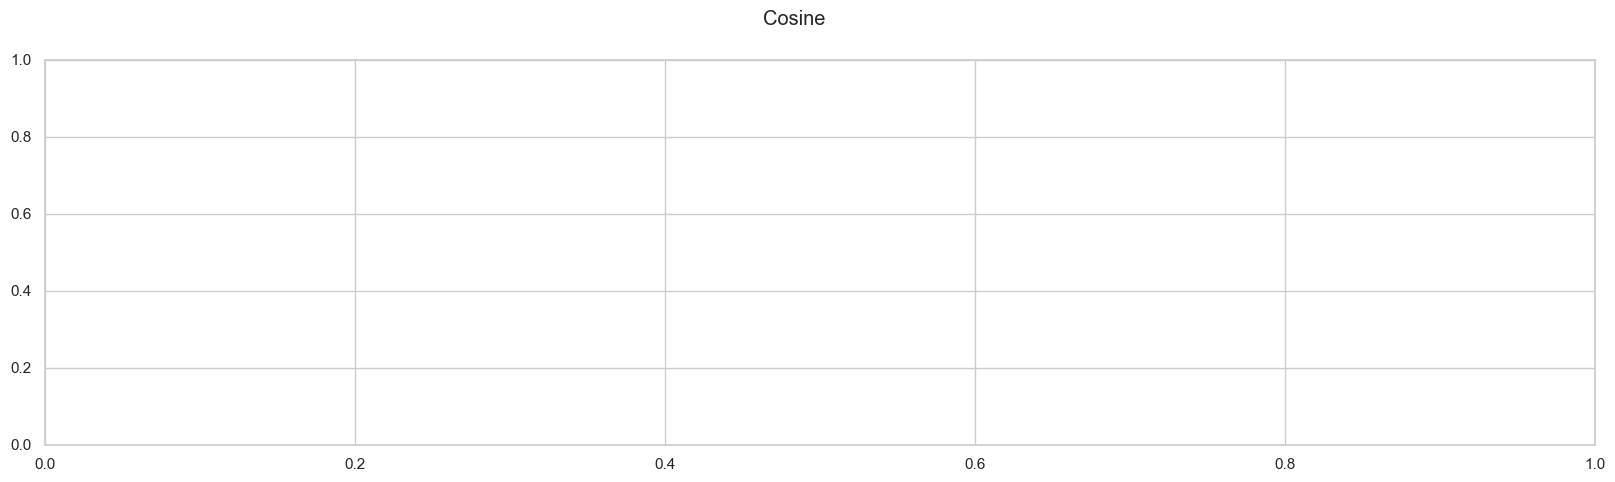

In [19]:
seaborn.set(style = 'whitegrid')  
ys = ["Cosine", "Rouge"]

# between questions, each violin plot only has 3 data points
for y in ys:
    fig, axs = plt.subplots(ncols=len(baseline_compare["Model"].unique()), figsize=(20,5),  sharey=True)
    fig.suptitle(y)
    i = 0
    for model in baseline_compare["Model"].unique():  
        axs[i].title.set_text(model)
        axs[i].tick_params(labelrotation=45)                    
        seaborn.violinplot(x ="Question", 
                           y=y, 
                           hue="Language",
                           data = baseline_compare[baseline_compare["Model"]==model],
                           density_norm='count',
                           ax=axs[i])
        i+=1
    plt.figure()

In [ ]:
seaborn.set(style = 'whitegrid')  
ys = ["Cosine", "Rouge"]

# between questions, each violin plot only has 3 data points
for y in ys:
    fig, axs = plt.subplots(ncols=len(lang_compare["Model"].unique())+2, figsize=(30,5),  sharey=True)
    fig.suptitle(y)
    i = 0
    for model in lang_compare["Model"].unique():  
        for b in [True, False]:
            axs[i].title.set_text(f"{model}_baseline{b}")
            axs[i].tick_params(labelrotation=45)                    
            seaborn.violinplot(x ="Question", 
                               y=y, 
                               hue="Language1-Language2",
                               data = lang_compare[(lang_compare["Model"]==model)&(lang_compare["fBaseline"]==b)],
                               density_norm='count',
                               ax=axs[i])
            i+=1
    plt.figure()

In [ ]:
seaborn.set(style = 'whitegrid')  
ys = ["Cosine", "Rouge"]

# not between questions, each violin plot has 24 data points
for y in ys:
    fig, axs = plt.subplots(ncols=len(lang_compare["Model"].unique()), figsize=(20,5),  sharey=True)
    fig.suptitle(y)
    i = 0
    for model in lang_compare["Model"].unique():  
        axs[i].title.set_text(f"{model}")
        axs[i].tick_params(labelrotation=45)                    
        seaborn.violinplot(x ="Language1-Language2", 
                           y=y, 
                           hue="fBaseline",
                           data = lang_compare[(lang_compare["Model"]==model)],
                           density_norm='count',
                           ax=axs[i])
        i+=1
    plt.figure()

## See data

In [20]:
from datasets import load_from_disk, concatenate_datasets
import pickle
import json
from glob import glob

paths = glob("t0*")

In [21]:
answers = [load_from_disk(x) for x in paths]
answers = concatenate_datasets(answers)
with open("question_map.pkl", 'rb') as f:
    question_map = pickle.load(f)
with open("params.json", 'r') as f:
    params = json.load(f)
answers = answers.add_column("question_mapped", [question_map[x] for x in answers["question"]])

In [22]:
question_map

{'Wie was Napoleon Bonaparte?': 'Question 1',
 'Was Napoleon Bonaparte een held?': 'Question 2',
 'Was Napoleon Bonaparte een tiran?': 'Question 3',
 'Was Napoleon Bonaparte een schurk?': 'Question 4',
 'Hoe stichtte Napoleon zijn rijk in Europa?': 'Question 5',
 'Hoe werd Napoleon Bonaparte keizer van Frankrijk?': 'Question 6',
 "Werd Napoleon's aanspraak op keizerschap in Europa gesteund?": 'Question 7',
 "Welke invloed had Napoleon's heerschappij op Engeland en Nederland?": 'Question 8',
 'Was de impact van Napoleons heerschappij op Engeland en Nederland destructief?': 'Question 9',
 'Wat was de impact van Napoleon op Engeland en Nederland?': 'Question 10',
 'Was de impact van Napoleon op Engeland en Nederland destructief?': 'Question 11',
 'Who was Napoleon Bonaparte?': 'Question 1',
 'Was Napoleon Bonaparte a hero?': 'Question 2',
 'Was Napoleon Bonaparte a tyrant?': 'Question 3',
 'Was Napoleon Bonaparte a villain?': 'Question 4',
 'How did Napoleon establish his empire in Europe

In [23]:
answers = answers.to_pandas()

In [24]:
answers["answers"][1][0]

'De vraag of Napoleon Bonaparte een held was, hangt af van perspectief en criteria zoals moreel, historisch belang en impact.  **Pro-heldargumenten:**   - **Juridische vernieuwing:** Zijn Code Napoléon moderniseerde het rechtssysteem en bood gelijke rechten aan burgers, wat wereldwijd invloed heeft gehad, ook in Nederland en België.   - **Stabiliteit en orde:** Tijdens de chaos van de Franse Revolutie bracht hij stabiliteit en centralisatie, wat veel mensen als positief zagen.   - **Militaire talent:** Zijn tactiek en strategie in vroegere campagnes werden door sommigen bewonderd als genie.    **Contra-heldargumenten:**   - **Dictatoriale neigingen:** Hoewel hij begon als revolutionair, steeg hij uite'

In [ ]:
answers.to_csv("all_answers.csv", encoding="utf-8")

In [ ]:
all()